In [18]:
import math
import matplotlib.pyplot as plt

In [19]:
# ──────────────────────────────────────────────
#  КОНСТАНТЫ
# ──────────────────────────────────────────────
EPS = 1e-5
MAX_ITERS = 1000

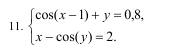

In [20]:
# ──────────────────────────────────────────────
#  ФУНКЦИИ 
# ──────────────────────────────────────────────
def f1(x, y):
    return math.cos(x - 1) + y - 0.8

def f2(x, y):
    return x - math.cos(y) - 2

In [21]:
# ──────────────────────────────────────────────
#  ГРАФИК
# ──────────────────────────────────────────────
def plot_graphs():
    # Сетка точек
    n = 400
    x = [1.0 + i * 2.0 / n for i in range(n + 1)]  # [1, 3]
    y = [-0.5 + i * 2.5 / n for i in range(n + 1)]  # [-0.5, 2]

    # Вычисляем F1 и F2 на сетке
    F1 = [[math.cos(xi - 1) + yj - 0.8 for yj in y] for xi in x]
    F2 = [[xi - math.cos(yj) - 2 for yj in y] for xi in x]

    # Транспонируем для contour
    F1_T = [[F1[i][j] for i in range(len(x))] for j in range(len(y))]
    F2_T = [[F2[i][j] for i in range(len(x))] for j in range(len(y))]

    plt.figure(figsize=(10, 10))

    # F1 = 0 (синий)
    plt.contour(x, y, F1_T, levels=[0], colors='blue', linewidths=2)
    # F2 = 0 (красный)
    plt.contour(x, y, F2_T, levels=[0], colors='red', linewidths=2)

    plt.grid(True, alpha=0.3)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title("blue — F1 = cos(x-1) + y - 0.8\nred — F2 = x - cos(y) - 2")
    plt.xlim([1, 3])
    plt.ylim([-0.5, 2])
    plt.xticks([i * 0.1 for i in range(10, 31)])
    plt.yticks([i * 0.1 for i in range(-5, 21)])
    plt.tight_layout()
    plt.show()

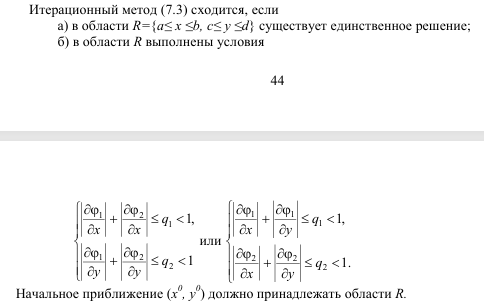

In [22]:
# ──────────────────────────────────────────────
#  МЕТОД ПРОСТОЙ ИТЕРАЦИИ
# ──────────────────────────────────────────────
def phi1(x, y):
    return 2 + math.cos(y)


def phi2(x, y):
    return 0.8 - math.cos(x - 1)


def dphi1_dx(x, y):
    return 0


def dphi1_dy(x, y):
    return -math.sin(y)


def dphi2_dx(x, y):
    return math.sin(x - 1)


def dphi2_dy(x, y):
    return 0


def simple_iters(x0, y0, eps):
    # --- Проверка сходимости ---
    a, b = 2.5, 2.7
    c, d = 0.8, 0.9

    print("   Проверка сходимости:")

    test_points = [
        (a, c), (a, d), (b, c), (b, d),
        ((a + b) / 2, (c + d) / 2),
        (x0, y0)
    ]

    q1_val = []
    q2_val = []

    for tp_x, tp_y in test_points:
        q1 = abs(dphi1_dx(tp_x, tp_y)) + abs(dphi1_dy(tp_x, tp_y))
        q2 = abs(dphi2_dx(tp_x, tp_y)) + abs(dphi2_dy(tp_x, tp_y))
        print(f"q1 = {q1:.6f}    q2 = {q2:.6f}")

        q1_val.append(q1)
        q2_val.append(q2)

    q1_max = max(q1_val)
    q2_max = max(q2_val)

    print(f"q1_max = {q1_max:.6f}")
    print(f"q2_max = {q2_max:.6f}")

    if q1_max < 1 and q2_max < 1:
        print("   Условия сходимости выполняются")
    else:
        print("   Условия сходимости НЕ выполняются")

    # --- Итерационный процесс (Гаусса-Зейделя) ---
    # Не выбрал Якоби, т.к. используются тсарые значения всех переменных
    # В Гаусса-Зейделя для вычисления y_new используется уже новое значение x_new, что ускоряет сходимость
    print("\n   Итерационный процесс:")

    x, y = x0, y0

    for iter in range(MAX_ITERS):
        x_old, y_old = x, y

        x_new = phi1(x_old, y_old)
        y_new = phi2(x_new, y_old)  # используем новый x (Гаусса-Зейделя)

        dx = abs(x_new - x_old)
        dy = abs(y_new - y_old)

        print(f"Итерация = {iter:<4} x = {x_new:<10.10f} y = {y_new:<10.10f} dx = {dx:<10.2e} dy = {dy:<10.2e}")

        if max(dx, dy) < eps:
            print(f"\nКоличество итераций: {iter}")
            print(f"Точность: {max(dx, dy):.2e}")
            print(f"x = {x_new:<10.10f} y = {y_new:<10.10f}")
            break

        x, y = x_new, y_new
    else:
        print("Максимальное число итераций достигнуто")

    # --- Проверка решения ---
    print("\n   Проверка решения:")

    f1 = math.cos(x_new - 1) + y_new - 0.8
    f2 = x_new - math.cos(y_new) - 2

    print(f"f1 = {f1:.2e}")
    print(f"f2 = {f2:.2e}")

    if abs(f1) < eps and abs(f2) < eps:
        print("Решение верно")
    else:
        print("Точность не достигнута для исходной системы")

    return x_new, y_new, iter

In [23]:
# ──────────────────────────────────────────────
#  МЕТОД НЬЮТОНА
# ──────────────────────────────────────────────
def newton(x0, y0, eps):
    """Метод Ньютона для системы нелинейных уравнений.
    На каждой итерации решаем J(x_k) * delta = -F(x_k),
    затем x_{k+1} = x_k + delta.
    """
    x, y = x0, y0

    print("\n   Итерационный процесс:")

    for iter in range(MAX_ITERS):
        # Сохраняем текущее приближение
        x_k, y_k = x, y

        # Вычисляем значения функций F(x_k, y_k)
        F1 = f1(x_k, y_k)
        F2 = f2(x_k, y_k)

        # Вычисляем элементы матрицы Якоби J(x_k, y_k):
        # J = [[∂f₁/∂x, ∂f₁/∂y],
        #      [∂f₂/∂x, f₂/∂y]]
        # ∂f₁/∂x = -sin(x-1),  ∂f₁/∂y = 1
        # ∂f₂/∂x = 1,          ∂f₂/∂y = sin(y)
        j11 = -math.sin(x_k - 1)
        j12 = 1.0
        j21 = 1.0
        j22 = math.sin(y_k)

        # Определитель матрицы Якоби
        det = j11 * j22 - j12 * j21

        # Проверка на вырожденность матрицы
        if abs(det) < 1e-12:
            print(f"Матрица вырождена на итерации: {iter}")
            break

        # Решаем систему J * [dx, dy]^T = -F по правилу Крамера:
        # dx = det([-F1, j12], [-F2, j22]) / det
        # dy = det([j11, -F1], [j21, -F2]) / det
        dx = ((-F1) * j22 - j12 * (-F2)) / det
        dy = (j11 * (-F2) - (-F1) * j21) / det

        # Обновляем приближение: x_{k+1} = x_k + dx
        x_new = x_k + dx
        y_new = y_k + dy

        # Норма шага (евклидова норма вектора поправки)
        z_k = math.sqrt(dx**2 + dy**2)

        # Вычисляем невязку на новом приближении
        f1_val = f1(x_new, y_new)
        f2_val = f2(x_new, y_new)

        print(f"Итерация = {iter:<4} x = {x_new:<10.10f} y = {y_new:<10.10f} z = {z_k:<10.10f} f1 = {abs(f1_val):<10.18f} f2 = {abs(f2_val):<12.18f}")

        # Критерий остановки: норма шага меньше заданной точности
        if z_k < eps:
            x, y = x_new, y_new
            print(f"\nКоличество итераций: {iter}")
            print(f"Точность: {max(f1_val, f2_val)}")
            print(f"x = {x:<10.10f} y = {y:<10.10f}")
            break

        # Переходим к следующей итерации
        x, y = x_new, y_new
    else:
        print("Превышен лимит итераций")

    # --- Проверка найденного решения ---
    print("\nПроверка:")

    fv1 = f1(x, y)
    fv2 = f2(x, y)

    print(f"f1 = {fv1:.2e}")
    print(f"f2 = {fv2:.2e}")

    if abs(fv1) < eps and abs(fv2) < eps:
        print("Решение верно")
    else:
        print("Точность не достигнута для исходной системы")

    return x, y, iter

## Теоретические вопросы

### 1. Как брать начальное приближение корня?

**Графический способ:** строим графики двух уравнений и визуально определяем точку пересечения. Для нашей системы:
- $y = 0.8 - \cos(x - 1)$
- $x = 2 + \cos(y)$

По графику видно, что корень находится примерно в области $x \approx 2.6,\ y \approx 0.9$.

**Аналитическая оценка:** из второго уравнения $x = 2 + \cos(y)$, так как $\cos(y) \in [-1, 1]$, то $x \in [1, 3]$. Из первого уравнения $y = 0.8 - \cos(x-1)$, так как $\cos \in [-1, 1]$, то $y \in [-0.2, 1.8]$.

### 2. Как остановить процесс уточнения корня?

Используем критерий остановки по разности соседних приближений:
- $|x_{k+1} - x_k| < \varepsilon$ и $|y_{k+1} - y_k| < \varepsilon$

Также можно использовать норму невязки: $\|F(x_k, y_k)\| < \varepsilon$.

Дополнительно ставим ограничение на максимальное число итераций (MAX_ITERS = 1000) для предотвращения зацикливания.

### 3. Как проверить правильность нахождения корня?

Подставляем найденные значения $(x^*, y^*)$ в исходные уравнения и проверяем, что невязка мала:
- $|f_1(x^*, y^*)| < \varepsilon$
- $|f_2(x^*, y^*)| < \varepsilon$

### 4. Преимущества и ограничения методов

**Метод простой итерации:**
- Прост в реализации, не требует вычисления производных
- Гарантированная сходимость при выполнении условия сжатия ($\|\Phi'\| < 1$)
- Медленная (линейная) сходимость
- Требует приведения системы к виду $x = \phi_1(x,y),\ y = \phi_2(x,y)$ с условием сжатия

**Метод Ньютона:**
- Квадратичная сходимость вблизи корня (очень быстрый)
- Требует вычисления Якобиана и его невырожденности
- Может расходиться при плохом начальном приближении
- На каждой итерации нужно решать систему линейных уравнений

### 5. Сравнение числа итераций

Метод Ньютона значительно быстрее метода простой итерации (квадратичная vs линейная сходимость), но требует больше вычислений на каждой итерации (Якобиан, определитель, решение СЛАУ).

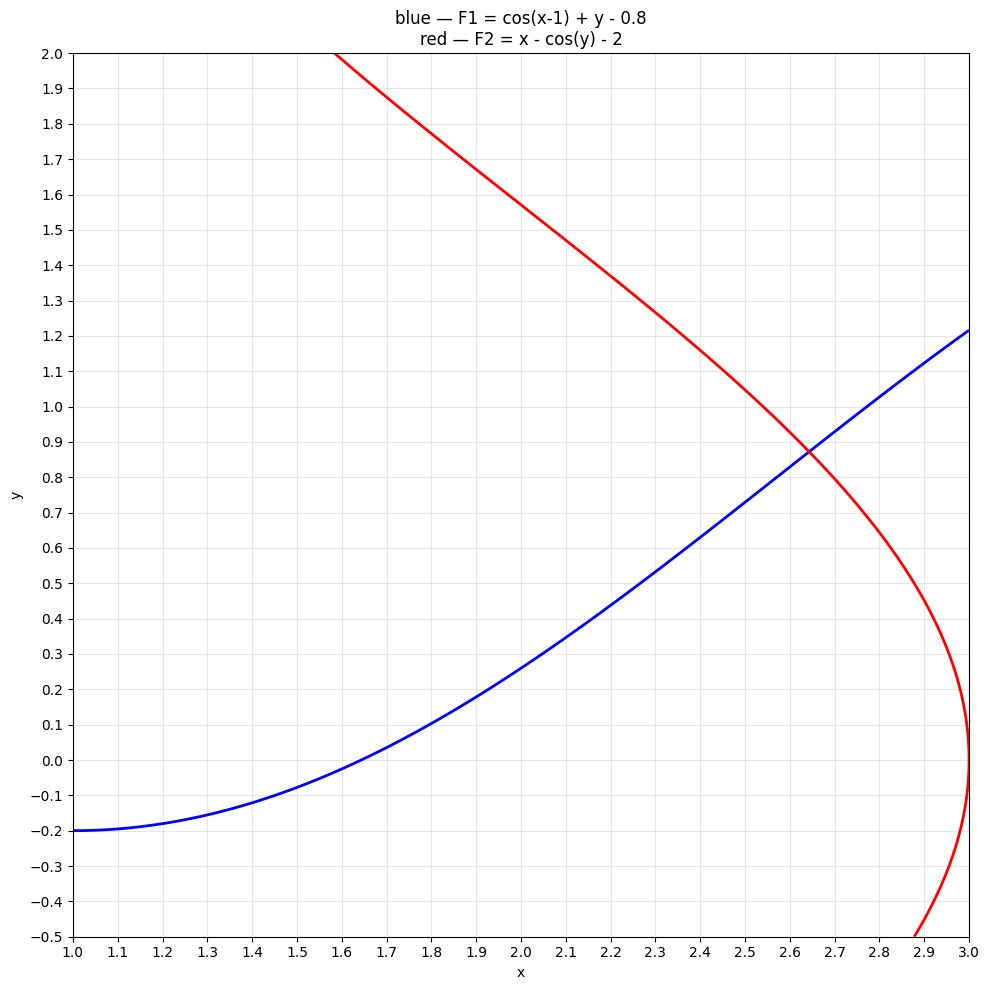


--- МЕТОД ПРОСТОЙ ИТЕРАЦИИ ---
   Проверка сходимости:
q1 = 0.717356    q2 = 0.997495
q1 = 0.783327    q2 = 0.997495
q1 = 0.717356    q2 = 0.991665
q1 = 0.783327    q2 = 0.991665
q1 = 0.751280    q2 = 0.999574
q1 = 0.717356    q2 = 0.997495
q1_max = 0.783327
q2_max = 0.999574
   Условия сходимости выполняются

   Итерационный процесс:
Итерация = 0    x = 2.6967067093 y = 0.9255779610 dx = 1.97e-01   dy = 1.26e-01  
Итерация = 1    x = 2.6013729202 y = 0.8305718291 dx = 9.53e-02   dy = 9.50e-02  
Итерация = 2    x = 2.6744536791 y = 0.9034718216 dx = 7.31e-02   dy = 7.29e-02  
Итерация = 3    x = 2.6188866561 y = 0.8480717952 dx = 5.56e-02   dy = 5.54e-02  
Итерация = 4    x = 2.6614305405 y = 0.8905101780 dx = 4.25e-02   dy = 4.24e-02  
Итерация = 5    x = 2.6290154998 y = 0.8581862898 dx = 3.24e-02   dy = 3.23e-02  
Итерация = 6    x = 2.6538109011 y = 0.8829192591 dx = 2.48e-02   dy = 2.47e-02  
Итерация = 7    x = 2.6348984460 y = 0.8640582281 dx = 1.89e-02   dy = 1.89e-02  
Итерац

In [24]:
if __name__ == "__main__":
    plot_graphs()

    # Начальное приближение по графику: x ~ 2.6, y ~ 0.9
    x0, y0 = 2.5, 0.8

    print("\n--- МЕТОД ПРОСТОЙ ИТЕРАЦИИ ---")
    x_simple, y_simple, i_simple = simple_iters(x0, y0, EPS)

    print(f"\nx = {x_simple:.10f}, y = {y_simple:.10f}")
    print(f"Итераций: {i_simple}")

    print("\n--- МЕТОД НЬЮТОНА ---")
    x_newton, y_newton, i_newton = newton(x0, y0, EPS)

    print(f"\nx = {x_newton:.10f}, y = {y_newton:.10f}")
    print(f"Итераций: {i_newton}")